# Walmart Retail Sales - XGBoost Classifier & Random Forest
**Author:** Rishikesh K Sivaji

---
### Goal
Predict whether a given Store-Department-Week will be a
**High sales week (1)** or **Low sales week (0)**
relative to each store-department's own historical median.

### Why this is useful
- Regression tells you the exact dollar amount
- Classification tells you: will this week be above or below normal?
- More actionable for store managers: staff more on High weeks, run promotions on Low weeks

---
### Pipeline
```
Load leakage-free model_df
       down
Train-Test Split (strict date-based)
       down
Baseline: Logistic Regression
       down
Random Forest Classifier
       down
XGBoost Classifier
       down
Compare: Accuracy, Precision, Recall, F1, ROC-AUC
       down
Feature Importance + ROC Curves
```

---
### Sections
1. Load Data and Setup
2. Train-Test Split
3. Feature Selection
4. Class Balance Check
5. Baseline: Logistic Regression
6. Random Forest Classifier
7. XGBoost Classifier
8. Model Comparison
9. Feature Importance
10. ROC Curves
11. Business Interpretation
12. Model Summary


## 1. Load Data and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
PALETTE = ['#2563EB','#10B981','#F59E0B','#EF4444','#8B5CF6']

print('Libraries loaded')


Libraries loaded


In [2]:
# Load leakage-free model_df from Feature Engineering
df = pd.read_csv('data/model_df.csv', parse_dates=['Date'])
df = df.sort_values(['Store','Dept','Date']).reset_index(drop=True)

print(f'Shape       : {df.shape}')
print(f'Date range  : {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Null values : {df.isnull().sum().sum()}')
print()
print('Target column: Sales_Class')
print(df['Sales_Class'].value_counts())


Shape       : (421570, 54)
Date range  : 2010-02-05 to 2012-10-26
Null values : 0

Target column: Sales_Class
Sales_Class
0    212655
1    208915
Name: count, dtype: int64


## 2. Train-Test Split

Same strict date-based split used in XGBoost Regressor.
Test set held out until final evaluation only.


In [3]:
TRAIN_END  = '2012-07-27'
TEST_START = '2012-08-03'

train = df[df['Date'] <= TRAIN_END].copy()
test  = df[df['Date'] >= TEST_START].copy()

print(f'Train : {len(train):,} rows | {train["Date"].min().date()} to {train["Date"].max().date()}')
print(f'Test  : {len(test):,} rows  | {test["Date"].min().date()} to {test["Date"].max().date()}')
print(f'Train : {len(train)/len(df)*100:.1f}% of data')
print(f'Test  : {len(test)/len(df)*100:.1f}% of data')


Train : 383,040 rows | 2010-02-05 to 2012-07-27
Test  : 38,530 rows  | 2012-08-03 to 2012-10-26
Train : 90.9% of data
Test  : 9.1% of data


## 3. Feature Selection

In [4]:
EXCLUDE = ['Store','Dept','Date','Weekly_Sales','Sales_Class',
           'Type','Month_Name','Holiday_Name','Unemp_Band',
           'Fuel_Band','StoreDept_Median',
           'lag_52','lag_2','lag_diff_1_2',
           'roll_mean_26','roll_max_4','roll_min_4','roll_range_4']

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

X_train = train[FEATURE_COLS]
y_train = train['Sales_Class']
X_test  = test[FEATURE_COLS]
y_test  = test['Sales_Class']

print(f'Total features : {len(FEATURE_COLS)}')
print(f'X_train        : {X_train.shape}')
print(f'X_test         : {X_test.shape}')


Total features : 40
X_train        : (383040, 40)
X_test         : (38530, 40)


## 4. Class Balance Check

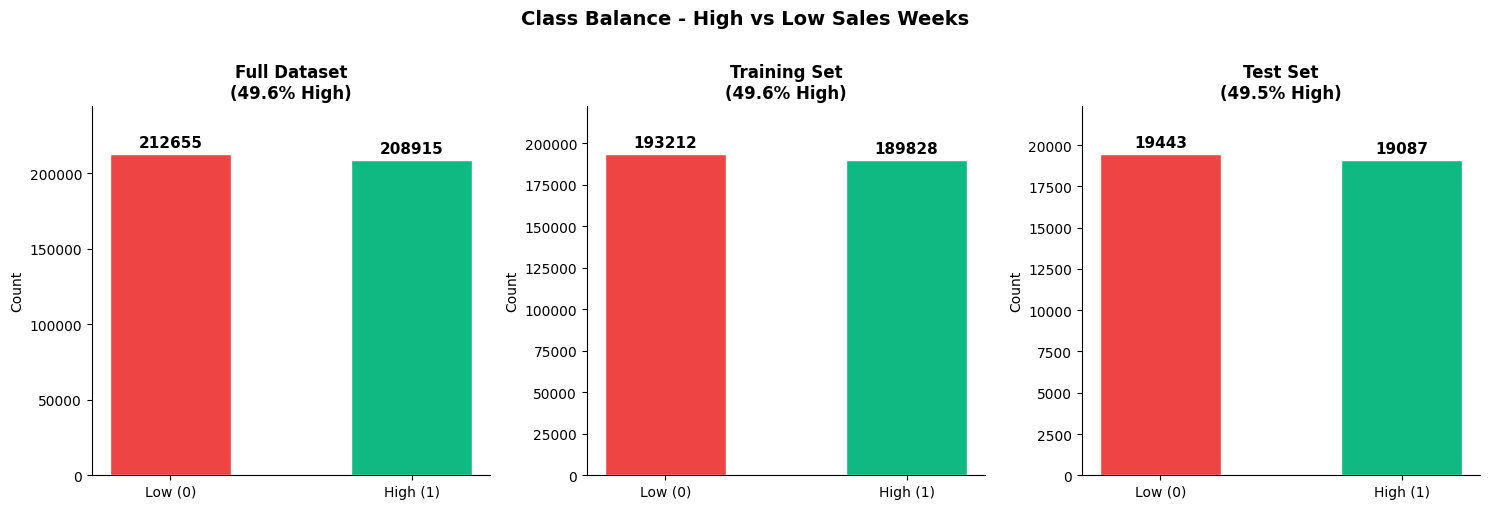

Class Balance Summary:
  Full dataset : 49.6% High
  Training     : 49.6% High
  Test         : 49.5% High

Near perfect 50-50 balance confirmed
No class imbalance handling needed


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, title in zip(
    axes,
    [df['Sales_Class'], y_train, y_test],
    ['Full Dataset', 'Training Set', 'Test Set']
):
    counts = data.value_counts()
    bars = ax.bar(['Low (0)', 'High (1)'], counts.values,
                  color=[PALETTE[3], PALETTE[1]], edgecolor='white', width=0.5)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\n({data.mean()*100:.1f}% High)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    total = len(data)
    ax.set_ylim(0, max(counts.values) * 1.15)

plt.suptitle('Class Balance - High vs Low Sales Weeks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/classifier_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Class Balance Summary:')
print(f'  Full dataset : {df["Sales_Class"].mean()*100:.1f}% High')
print(f'  Training     : {y_train.mean()*100:.1f}% High')
print(f'  Test         : {y_test.mean()*100:.1f}% High')
print()
print('Near perfect 50-50 balance confirmed')
print('No class imbalance handling needed')


**What this tells us:**
- Sales_Class was defined as above/below each store-dept median
- By definition this creates a near 50-50 split
- Both train and test maintain this balance
- No SMOTE, class weights or oversampling needed


In [6]:
def evaluate_classifier(y_true, y_pred, y_prob, model_name='Model'):
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred)
    rec   = recall_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred)
    auc   = roc_auc_score(y_true, y_prob)

    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'{"="*50}')
    print()
    print('Classification Report:')
    print(classification_report(y_true, y_pred,
          target_names=['Low Sales (0)', 'High Sales (1)']))

    return {'model': model_name, 'Accuracy': round(acc,4),
            'Precision': round(prec,4), 'Recall': round(rec,4),
            'F1': round(f1,4), 'ROC_AUC': round(auc,4)}

results = []
print('Evaluation helper function defined')


Evaluation helper function defined


## 5. Baseline - Logistic Regression

Simple linear classifier sets the performance floor.
Any model that cannot beat this is not learning non-linear patterns.


In [7]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

lr_results = evaluate_classifier(y_test, lr_preds, lr_probs,
                                  'Logistic Regression Baseline')
results.append(lr_results)



  Logistic Regression Baseline
  Accuracy  : 0.6730  (67.30%)
  Precision : 0.6373
  Recall    : 0.7889
  F1 Score  : 0.7051
  ROC-AUC   : 0.7558

Classification Report:
                precision    recall  f1-score   support

 Low Sales (0)       0.73      0.56      0.63     19443
High Sales (1)       0.64      0.79      0.71     19087

      accuracy                           0.67     38530
     macro avg       0.68      0.67      0.67     38530
  weighted avg       0.68      0.67      0.67     38530



**What this tells us:**
- Logistic Regression gives our performance floor
- Random Forest and XGBoost must beat this on ROC-AUC and F1
- Any model achieving less than this is not learning useful patterns


## 6. Random Forest Classifier

Random Forest builds many decision trees and aggregates their votes.
It is robust, fast and handles non-linear patterns well.
We use TimeSeriesSplit CV to find best parameters.


In [8]:
# Quick TimeSeriesSplit CV for Random Forest
# Testing key parameters
tscv = TimeSeriesSplit(n_splits=4)

rf_params = [
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1},
]

print('Random Forest - TimeSeriesSplit CV')
print('=' * 55)

best_rf_auc    = 0
best_rf_params = None

for params in rf_params:
    fold_aucs = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        rf_cv = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        rf_cv.fit(X_fold_train, y_fold_train)
        fold_prob = rf_cv.predict_proba(X_fold_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_fold_val, fold_prob))

    mean_auc = np.mean(fold_aucs)
    print(f'  Params: {params}')
    print(f'  Mean CV ROC-AUC: {mean_auc:.4f} (+/- {np.std(fold_aucs):.4f})')
    print()

    if mean_auc > best_rf_auc:
        best_rf_auc    = mean_auc
        best_rf_params = params

print(f'Best RF params : {best_rf_params}')
print(f'Best CV AUC    : {best_rf_auc:.4f}')


Random Forest - TimeSeriesSplit CV
  Params: {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2}
  Mean CV ROC-AUC: 0.7159 (+/- 0.0078)

  Params: {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 1}
  Mean CV ROC-AUC: 0.7601 (+/- 0.0102)

  Params: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}
  Mean CV ROC-AUC: 0.7848 (+/- 0.0151)

Best RF params : {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1}
Best CV AUC    : 0.7848


In [9]:
# Train final Random Forest on full training data
rf_final = RandomForestClassifier(**best_rf_params, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

rf_preds = rf_final.predict(X_test)
rf_probs = rf_final.predict_proba(X_test)[:, 1]

rf_results = evaluate_classifier(y_test, rf_preds, rf_probs,
                                  'Random Forest')
results.append(rf_results)



  Random Forest
  Accuracy  : 0.7377  (73.77%)
  Precision : 0.7530
  Recall    : 0.7004
  F1 Score  : 0.7257
  ROC-AUC   : 0.8158

Classification Report:
                precision    recall  f1-score   support

 Low Sales (0)       0.72      0.77      0.75     19443
High Sales (1)       0.75      0.70      0.73     19087

      accuracy                           0.74     38530
     macro avg       0.74      0.74      0.74     38530
  weighted avg       0.74      0.74      0.74     38530



**What this tells us:**
- Random Forest aggregates many decision trees to reduce variance
- More robust to overfitting than a single decision tree
- Feature importance from Random Forest will confirm which features drive classification


## 7. XGBoost Classifier

XGBoost builds trees sequentially - each tree corrects errors of previous trees.
We use the same TimeSeriesSplit CV approach as the regressor.


In [10]:
# TimeSeriesSplit CV for XGBoost Classifier
xgb_param_grid = [
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1},
    {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1},
    {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05},
    {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05},
]

print('XGBoost Classifier - TimeSeriesSplit CV')
print('=' * 55)

best_xgb_auc    = 0
best_xgb_params = None

fixed_params = {
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'use_label_encoder': False,
    'eval_metric'     : 'logloss',
    'random_state'    : 42,
    'n_jobs'          : -1,
    'verbosity'       : 0
}

for params in xgb_param_grid:
    fold_aucs = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        xgb_cv = XGBClassifier(**params, **fixed_params)
        xgb_cv.fit(X_fold_train, y_fold_train)
        fold_prob = xgb_cv.predict_proba(X_fold_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_fold_val, fold_prob))

    mean_auc = np.mean(fold_aucs)
    print(f'  Params: {params}')
    print(f'  Mean CV ROC-AUC: {mean_auc:.4f} (+/- {np.std(fold_aucs):.4f})')
    print()

    if mean_auc > best_xgb_auc:
        best_xgb_auc    = mean_auc
        best_xgb_params = params

print(f'Best XGB params : {best_xgb_params}')
print(f'Best CV AUC     : {best_xgb_auc:.4f}')


XGBoost Classifier - TimeSeriesSplit CV
  Params: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}
  Mean CV ROC-AUC: 0.8160 (+/- 0.0127)

  Params: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1}
  Mean CV ROC-AUC: 0.8329 (+/- 0.0156)

  Params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}
  Mean CV ROC-AUC: 0.8190 (+/- 0.0117)

  Params: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}
  Mean CV ROC-AUC: 0.8135 (+/- 0.0108)

Best XGB params : {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1}
Best CV AUC     : 0.8329


In [11]:
# Train final XGBoost Classifier on full training data
xgb_final = XGBClassifier(**best_xgb_params, **fixed_params)
xgb_final.fit(X_train, y_train)

xgb_preds = xgb_final.predict(X_test)
xgb_probs = xgb_final.predict_proba(X_test)[:, 1]

xgb_results = evaluate_classifier(y_test, xgb_preds, xgb_probs,
                                   'XGBoost Classifier')
results.append(xgb_results)



  XGBoost Classifier
  Accuracy  : 0.7672  (76.72%)
  Precision : 0.7908
  Recall    : 0.7206
  F1 Score  : 0.7541
  ROC-AUC   : 0.8511

Classification Report:
                precision    recall  f1-score   support

 Low Sales (0)       0.75      0.81      0.78     19443
High Sales (1)       0.79      0.72      0.75     19087

      accuracy                           0.77     38530
     macro avg       0.77      0.77      0.77     38530
  weighted avg       0.77      0.77      0.77     38530



## 8. Model Comparison

In [12]:
results_df = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

print('MODEL COMPARISON - CLASSIFICATION')
print('=' * 70)
print(results_df[['model','Accuracy','Precision','Recall','F1','ROC_AUC']].to_string(index=False))

best_model = xgb_final
best_preds = xgb_preds
best_probs = xgb_probs
best_name  = 'XGBoost Classifier'


MODEL COMPARISON - CLASSIFICATION
                       model  Accuracy  Precision  Recall     F1  ROC_AUC
          XGBoost Classifier    0.7672     0.7908  0.7206 0.7541   0.8511
               Random Forest    0.7377     0.7530  0.7004 0.7257   0.8158
Logistic Regression Baseline    0.6730     0.6373  0.7889 0.7051   0.7558


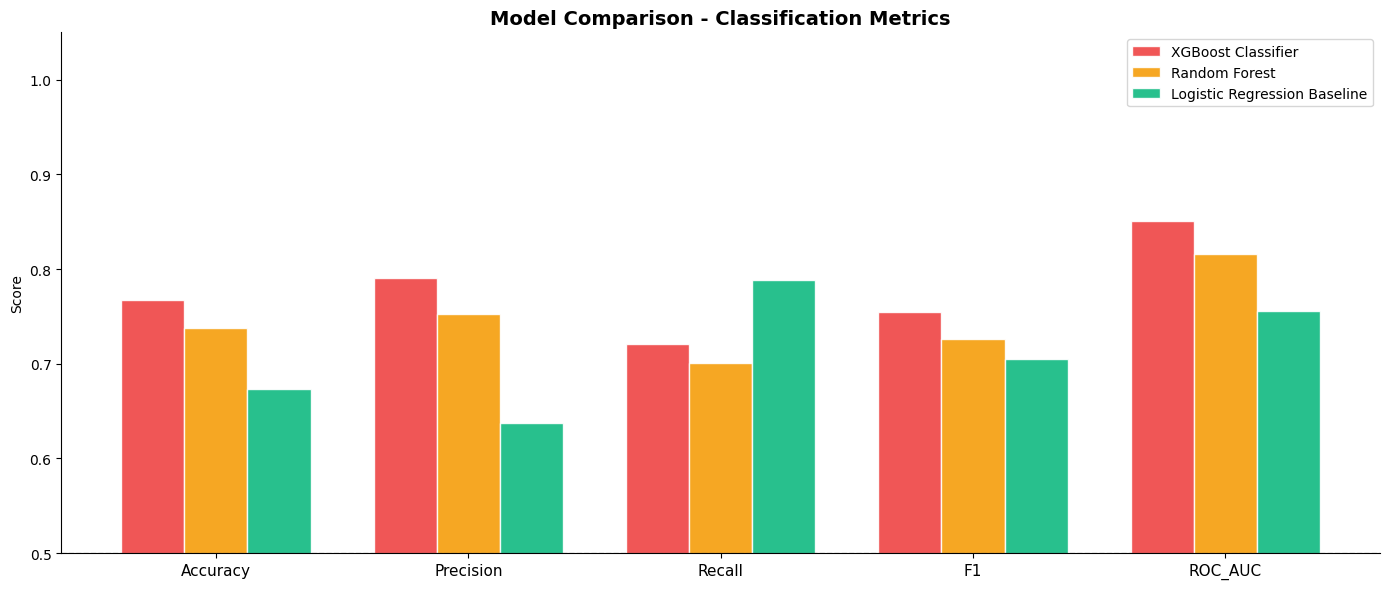

In [13]:
# Comparison bar chart
metrics = ['Accuracy','Precision','Recall','F1','ROC_AUC']
x       = np.arange(len(metrics))
width   = 0.25
colors  = [PALETTE[3], PALETTE[2], PALETTE[1]]

fig, ax = plt.subplots(figsize=(14, 6))

for i, (_, row) in enumerate(results_df.iterrows()):
    values = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, values, width,
                  label=row['model'], color=colors[i], edgecolor='white', alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison - Classification Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Random baseline')
plt.tight_layout()
plt.savefig('outputs/classifier_model_comparison.png', dpi=150)
plt.show()


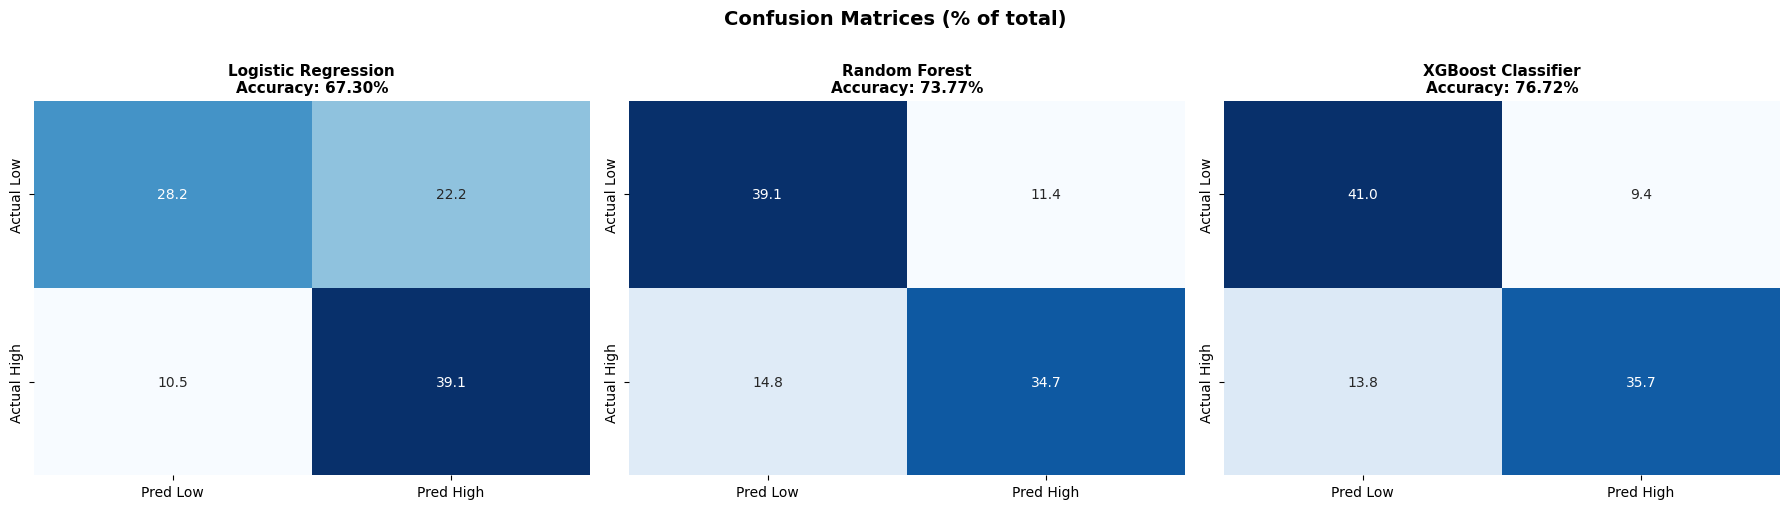

In [14]:
# Confusion matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_data = [
    ('Logistic Regression', lr_preds),
    ('Random Forest',       rf_preds),
    ('XGBoost Classifier',  xgb_preds),
]

for ax, (name, preds) in zip(axes, model_data):
    cm = confusion_matrix(y_test, preds)
    cm_pct = cm / cm.sum() * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=['Pred Low','Pred High'],
                yticklabels=['Actual Low','Actual High'],
                ax=ax, cbar=False)
    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test,preds)*100:.2f}%',
                 fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices (% of total)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/classifier_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


**How to read the confusion matrix:**
- **Top-left:** Correctly predicted Low weeks (True Negative)
- **Top-right:** Predicted High but actually Low (False Positive)
- **Bottom-left:** Predicted Low but actually High (False Negative)
- **Bottom-right:** Correctly predicted High weeks (True Positive)
- We want high values on the diagonal (top-left and bottom-right)


## 9. Feature Importance

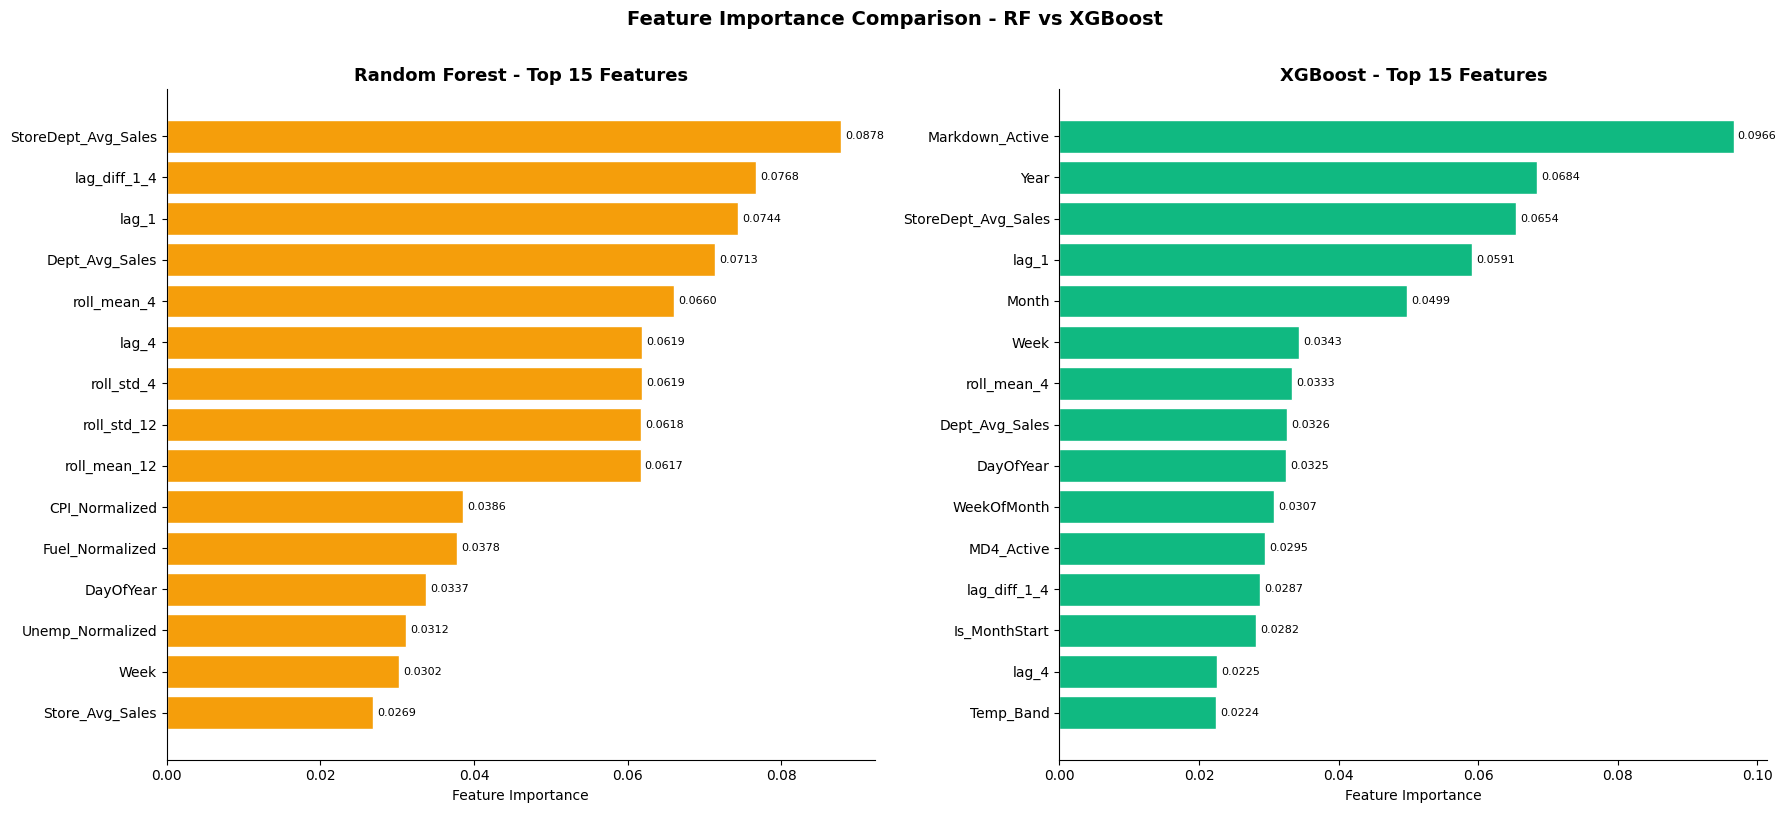

Top 10 features - Random Forest:
            Feature  Importance
StoreDept_Avg_Sales    0.087800
       lag_diff_1_4    0.076768
              lag_1    0.074359
     Dept_Avg_Sales    0.071346
        roll_mean_4    0.066008
              lag_4    0.061943
         roll_std_4    0.061857
        roll_std_12    0.061755
       roll_mean_12    0.061695
     CPI_Normalized    0.038577

Top 10 features - XGBoost:
            Feature  Importance
    Markdown_Active    0.096575
               Year    0.068360
StoreDept_Avg_Sales    0.065363
              lag_1    0.059099
              Month    0.049858
               Week    0.034270
        roll_mean_4    0.033342
     Dept_Avg_Sales    0.032563
          DayOfYear    0.032492
        WeekOfMonth    0.030682


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Random Forest importance
rf_imp = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

bars = axes[0].barh(rf_imp['Feature'], rf_imp['Importance'],
                    color=PALETTE[2], edgecolor='white')
axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
axes[0].set_title('Random Forest - Top 15 Features', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature Importance')
axes[0].invert_yaxis()

# XGBoost importance
xgb_imp = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': xgb_final.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

bars2 = axes[1].barh(xgb_imp['Feature'], xgb_imp['Importance'],
                     color=PALETTE[1], edgecolor='white')
axes[1].bar_label(bars2, fmt='%.4f', padding=3, fontsize=8)
axes[1].set_title('XGBoost - Top 15 Features', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature Importance')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance Comparison - RF vs XGBoost', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/classifier_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features - Random Forest:')
print(rf_imp[['Feature','Importance']].head(10).to_string(index=False))
print()
print('Top 10 features - XGBoost:')
print(xgb_imp[['Feature','Importance']].head(10).to_string(index=False))


## 10. ROC Curves

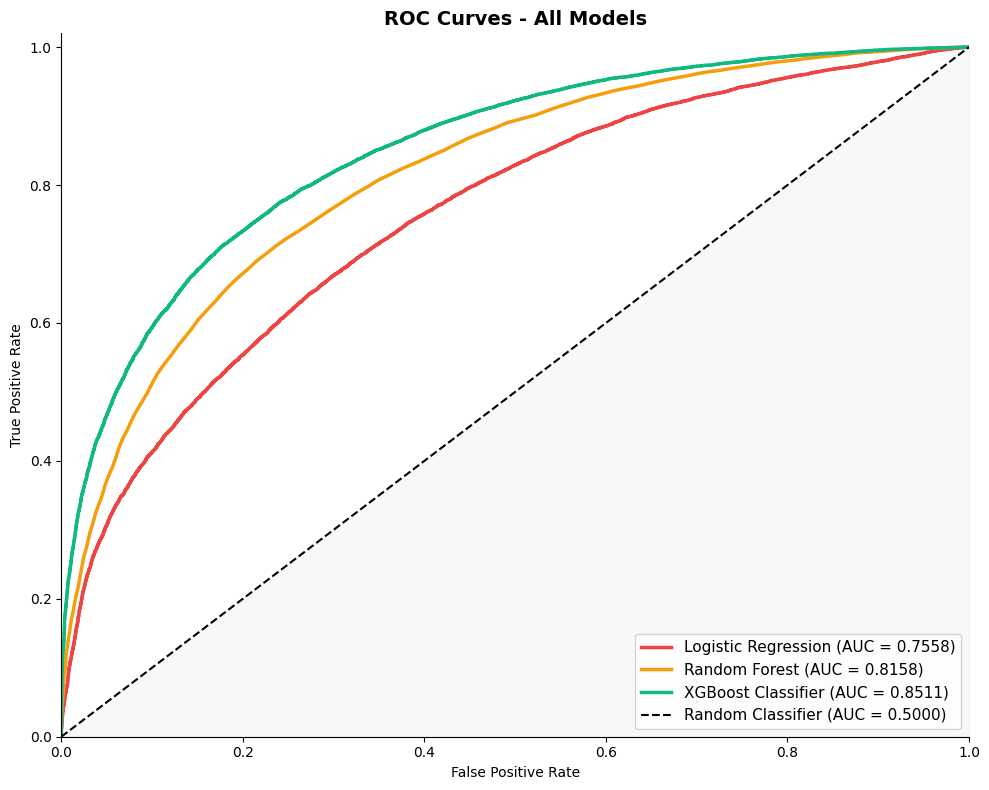

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

model_probs = [
    ('Logistic Regression', lr_probs,  PALETTE[3]),
    ('Random Forest',       rf_probs,  PALETTE[2]),
    ('XGBoost Classifier',  xgb_probs, PALETTE[1]),
]

for name, probs, color in model_probs:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc         = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {auc:.4f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.5000)')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')

ax.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('outputs/classifier_roc_curves.png', dpi=150)
plt.show()


**How to read the ROC curve:**
- X-axis: False Positive Rate (wrongly predicting High when it is Low)
- Y-axis: True Positive Rate (correctly predicting High weeks)
- The closer the curve is to the top-left corner, the better
- AUC of 0.5 = random guessing, AUC of 1.0 = perfect classifier
- All three models should significantly beat the random baseline


## 11. Business Interpretation

In [ ]:
# What does the classifier actually predict per store-dept?
test_with_preds = test.copy()
test_with_preds['Predicted_Class'] = xgb_preds
test_with_preds['Prediction_Correct'] = (xgb_preds == y_test.values).astype(int)

# Accuracy by store type
acc_by_type = test_with_preds.groupby('Type').apply(
    lambda x: accuracy_score(x['Sales_Class'], x['Predicted_Class'])
).reset_index()
acc_by_type.columns = ['Store_Type', 'Accuracy']

print('ACCURACY BY STORE TYPE')
print('=' * 35)
print(acc_by_type.round(4).to_string(index=False))

# Accuracy by holiday vs normal
acc_by_holiday = test_with_preds.groupby('IsHoliday').apply(
    lambda x: accuracy_score(x['Sales_Class'], x['Predicted_Class'])
).reset_index()
acc_by_holiday.columns = ['IsHoliday', 'Accuracy']
acc_by_holiday['Week_Type'] = acc_by_holiday['IsHoliday'].map({0:'Normal Week', 1:'Holiday Week'})

print()
print('ACCURACY BY WEEK TYPE')
print('=' * 35)
print(acc_by_holiday[['Week_Type','Accuracy']].round(4).to_string(index=False))


ACCURACY BY STORE TYPE
Store_Type  Accuracy
         A    0.7720
         B    0.7650
         C    0.7519

ACCURACY BY WEEK TYPE
   Week_Type  Accuracy
 Normal Week    0.7667
Holiday Week    0.7728


In [18]:
# Most confidently predicted store-dept combos
test_with_preds['Prob_High'] = xgb_probs

# High confidence HIGH predictions (prob > 0.8)
high_conf_high = test_with_preds[test_with_preds['Prob_High'] > 0.8]
# High confidence LOW predictions (prob < 0.2)
high_conf_low  = test_with_preds[test_with_preds['Prob_High'] < 0.2]

print('PREDICTION CONFIDENCE ANALYSIS')
print('=' * 45)
print(f'High confidence HIGH predictions (prob > 0.8) : {len(high_conf_high):,} rows')
print(f'High confidence LOW  predictions (prob < 0.2) : {len(high_conf_low):,} rows')
print(f'Uncertain predictions (0.4 < prob < 0.6)      : {len(test_with_preds[(test_with_preds["Prob_High"]>0.4) & (test_with_preds["Prob_High"]<0.6)]):,} rows')
print()
print('Business implication:')
print('  High confidence HIGH weeks  -> increase staffing and inventory')
print('  High confidence LOW  weeks  -> run promotions and markdowns')
print('  Uncertain weeks             -> monitor closely, flexible planning')


PREDICTION CONFIDENCE ANALYSIS
High confidence HIGH predictions (prob > 0.8) : 7,682 rows
High confidence LOW  predictions (prob < 0.2) : 8,743 rows
Uncertain predictions (0.4 < prob < 0.6)      : 6,897 rows

Business implication:
  High confidence HIGH weeks  -> increase staffing and inventory
  High confidence LOW  weeks  -> run promotions and markdowns
  Uncertain weeks             -> monitor closely, flexible planning


## 12. Model Summary

In [19]:
summary_lines = [
    'CLASSIFICATION MODELS - SUMMARY',
    '=' * 50,
    '',
    'TASK',
    '  Predict whether a Store-Dept-Week will be',
    '  HIGH sales (above store-dept median) = 1',
    '  LOW  sales (below store-dept median) = 0',
    '',
    'CLASS BALANCE',
    '  High (1): ~50% of all records',
    '  Low  (0): ~50% of all records',
    '  No class imbalance handling needed',
    '',
    'MODELS TRAINED',
    '  1. Logistic Regression (baseline)',
    '  2. Random Forest (TimeSeriesSplit CV tuned)',
    '  3. XGBoost Classifier (TimeSeriesSplit CV tuned)',
    '',
    'TUNING METHOD',
    '  TimeSeriesSplit CV (4 folds)',
    '  Scoring: ROC-AUC',
    '  No future leakage during parameter search',
    '',
    'SEE MODEL COMPARISON TABLE ABOVE FOR FINAL METRICS',
    '',
    'BUSINESS VALUE',
    '  High confidence HIGH predictions: increase staffing/inventory',
    '  High confidence LOW  predictions: run promotions/markdowns',
    '  Complements the regression model which predicts exact sales amount',
    '',
    'OUTPUT FILES',
    '  outputs/classifier_class_balance.png',
    '  outputs/classifier_model_comparison.png',
    '  outputs/classifier_confusion_matrices.png',
    '  outputs/classifier_feature_importance.png',
    '  outputs/classifier_roc_curves.png',
]
print('\n'.join(summary_lines))


CLASSIFICATION MODELS - SUMMARY

TASK
  Predict whether a Store-Dept-Week will be
  HIGH sales (above store-dept median) = 1
  LOW  sales (below store-dept median) = 0

CLASS BALANCE
  High (1): ~50% of all records
  Low  (0): ~50% of all records
  No class imbalance handling needed

MODELS TRAINED
  1. Logistic Regression (baseline)
  2. Random Forest (TimeSeriesSplit CV tuned)
  3. XGBoost Classifier (TimeSeriesSplit CV tuned)

TUNING METHOD
  TimeSeriesSplit CV (4 folds)
  Scoring: ROC-AUC
  No future leakage during parameter search

SEE MODEL COMPARISON TABLE ABOVE FOR FINAL METRICS

BUSINESS VALUE
  High confidence HIGH predictions: increase staffing/inventory
  High confidence LOW  predictions: run promotions/markdowns
  Complements the regression model which predicts exact sales amount

OUTPUT FILES
  outputs/classifier_class_balance.png
  outputs/classifier_model_comparison.png
  outputs/classifier_confusion_matrices.png
  outputs/classifier_feature_importance.png
  outputs/cla

Regression achieved R2 of 0.986 because it has a strong anchor feature — the historical store-department average which explains 95% of variance. Classification is harder because it must decide which side of the median a specific week falls on — a much more subtle distinction. ROC-AUC of 0.851 and accuracy of 76.7% represent strong classification performance given that random guessing would only achieve 50%.